<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): CapeFlats
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 846 | Val: 205 | Test: 1476


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 4.89e-04 | train loss 1.1355 acc 0.481 | val loss 0.8673 acc 0.673 *


[EfficientNet-B0] Epoch   2/100 | LR: 4.89e-04 | train loss 0.7195 acc 0.667 | val loss 0.6366 acc 0.761 *


[EfficientNet-B0] Epoch   3/100 | LR: 4.89e-04 | train loss 0.5296 acc 0.758 | val loss 0.4411 acc 0.815 *


[EfficientNet-B0] Epoch   4/100 | LR: 4.89e-04 | train loss 0.4074 acc 0.816 | val loss 0.4002 acc 0.824 *


...

[EfficientNet-B0] Epoch  27/100 | LR: 4.89e-09 | train loss 0.2109 acc 0.898 | val loss 0.3481 acc 0.839


[EfficientNet-B0] Epoch  28/100 | LR: 4.89e-09 | train loss 0.2366 acc 0.870 | val loss 0.3318 acc 0.859


[EfficientNet-B0] Epoch  29/100 | LR: 4.89e-09 | train loss 0.2078 acc 0.894 | val loss 0.3396 acc 0.849


[EfficientNet-B0] Epoch  30/100 | LR: 4.89e-10 | train loss 0.2223 acc 0.868 | val loss 0.3264 acc 0.854


[EfficientNet-B0] Epoch  31/100 | LR: 4.89e-10 | train loss 0.2425 acc 0.884 | val loss 0.3425 acc 0.849

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 31.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3233)


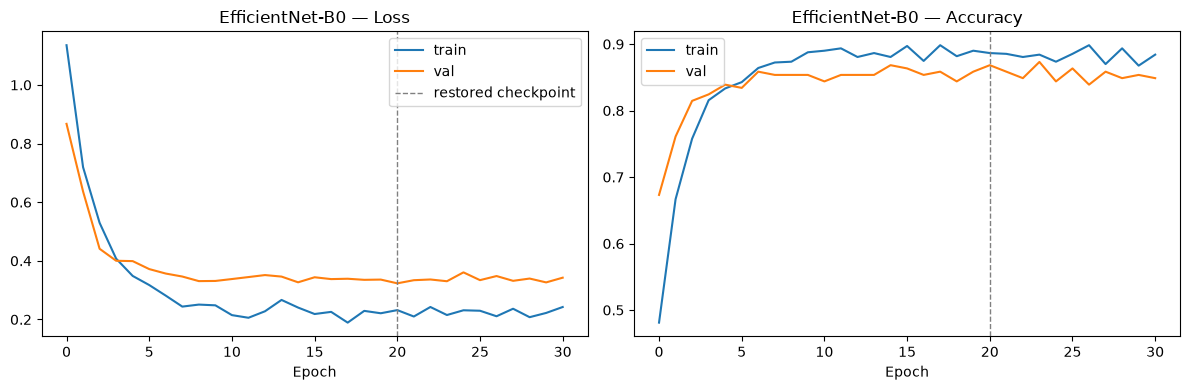

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.687


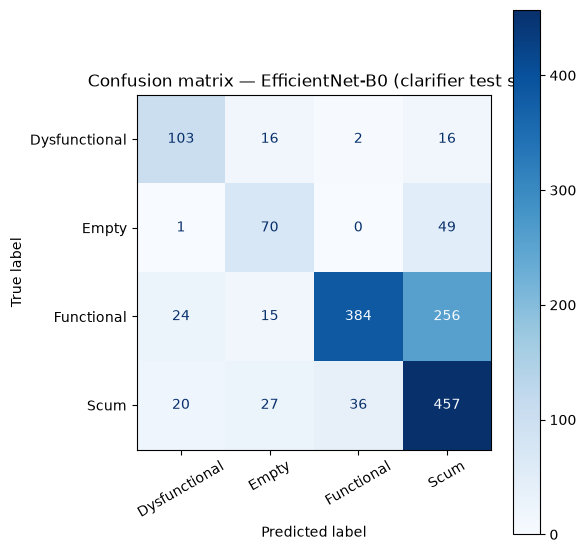

               precision    recall  f1-score   support

Dysfunctional      0.696     0.752     0.723       137
        Empty      0.547     0.583     0.565       120
   Functional      0.910     0.566     0.698       679
         Scum      0.587     0.846     0.693       540

     accuracy                          0.687      1476
    macro avg      0.685     0.687     0.670      1476
 weighted avg      0.743     0.687     0.688      1476



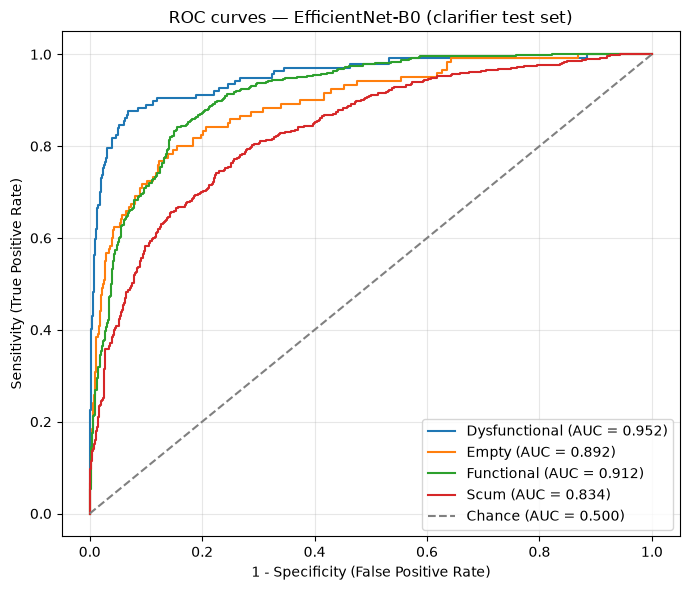

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.952
  Empty          : 0.892
  Functional     : 0.912
  Scum           : 0.834

Mean AUC (over 4/4 classes with test examples): 0.898


(np.float64(0.6869918699186992),
 {'Dysfunctional': 0.9520177929929188,
  'Empty': 0.8922627826941987,
  'Functional': 0.9122999909454268,
  'Scum': 0.833960509654954})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/clarifier_aug/results_clarifier_efficientnet_b0_CapeFlats.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
